# ¿Alcanza el gas en el día más frío?

El notebook 01 mostró que el consumo total de invierno está topeado: cuando hace frío, se
prioriza a los hogares y se corta a industrias, estaciones de GNC y centrales. Acá se mira ese
tope día por día, con los partes diarios del ENARGAS desde 2014: cuánto consumió cada
distribuidora, cuánto gas entró al sistema, cuánto de eso fue GNL por barco y cuánto vino por el
norte.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent / "src"))
from datetime import date
import numpy as np, pandas as pd
from IPython.display import Image, display
from glab import DISTRIBUIDORAS, FIGURES, DATA_PROC
from glab.series import fetch, per_day, annual
from glab.clima import daily_table, weights, national, monthly, cdd
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)
FIGURES.mkdir(parents=True, exist_ok=True)
df = fetch()
T = daily_table()
w = weights(df[list(DISTRIBUIDORAS)])
H = national(T, w)                                   # grados-día de calefacción diarios, promedio nacional ponderado
clima = pd.DataFrame({"hdd": monthly(H), "cdd": monthly(national(T, w, cdd))})
print(f"series: {df.index.min():%m/%Y} a {df.index.max():%m/%Y}; temperatura: {T.index.min():%d/%m/%Y} a {T.index.max():%d/%m/%Y}")
from glab.partes import daily_table as partes_table
from glab.pico import (daily_frame, winter, fit_priority, unconstrained_direct, overhead, winter_ensemble, season_gap, thermal,
                       gnl_response, gnl_ensemble, M3_POR_BUQUE)
P = partes_table(date(2014, 1, 1), date(2026, 9, 24), cache=DATA_PROC / "partes_diarios.parquet")
D = daily_frame(P, H)
print(f"partes leídos: {len(P)} días, de {P.fecha.min():%d/%m/%Y} a {P.fecha.max():%d/%m/%Y}")

series: 01/1996 a 06/2026; temperatura: 01/01/1996 a 19/09/2026
partes leídos: 4626 días, de 01/01/2014 a 01/09/2026


## 1. Cómo se cubrió cada invierno, 2014 a 2026

De mayo a septiembre de cada año: cuánto GNL entró por barco (Escobar y Bahía Blanca), cuánto por
el norte (Bolivia hasta 2024; desde 2025 el gasoducto Norandino, que trae gas desde Chile) y el
máximo diario de gas propio que entró al sistema. Antes de 2019 el parte no separa el gas de
Bolivia de la producción del norte: esos años quedan sin dato de importación por el norte, y su
"gas propio" incluye el boliviano. Desde 2019 algunos días el PDF no imprime la nota; como el
caudal es estable, se interpola entre los días vecinos (la columna `norte_informado_pct` dice
qué parte del invierno es dato directo).

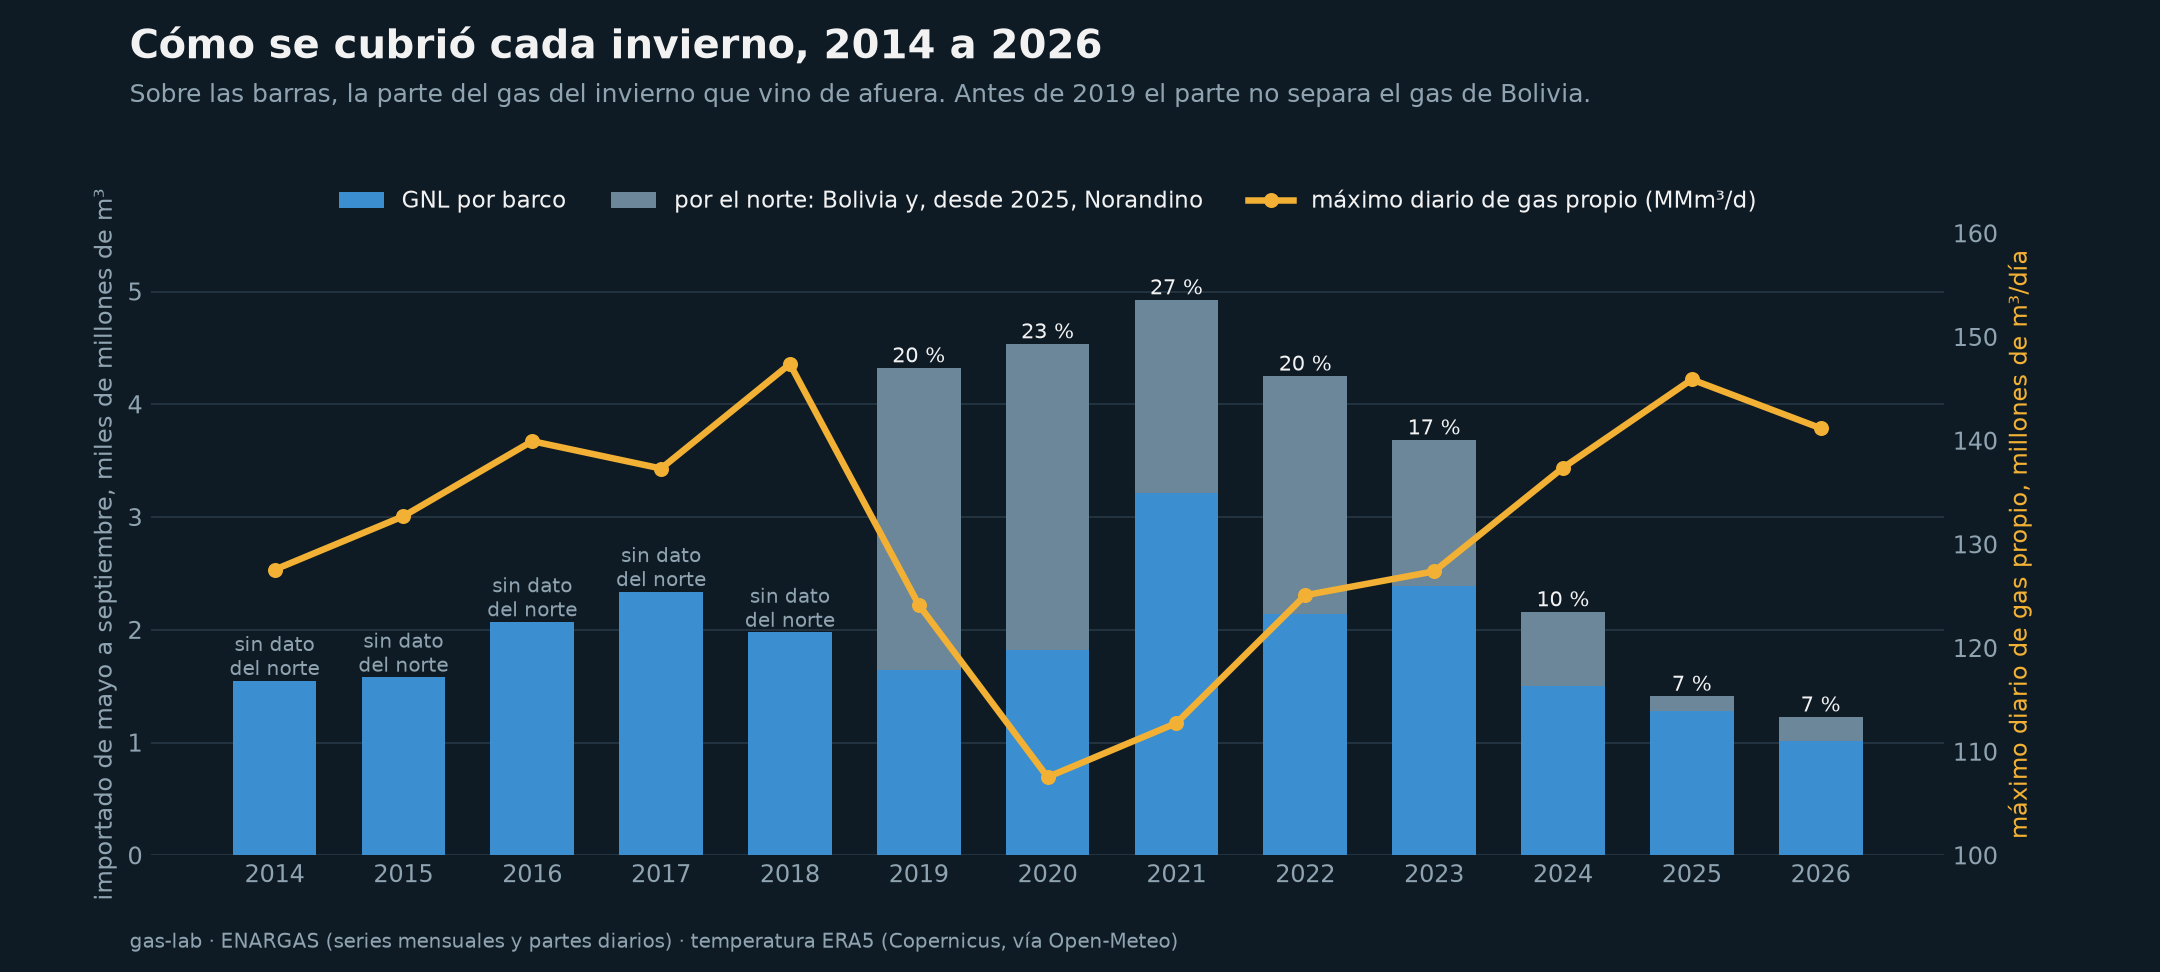

correlación entre el GNL de cada invierno y sus grados-día, 2021-2026: -0.19


,dias,grados_dia,prioritaria_max,inyeccion_max,domestico_max,gnl_mm3,buques,dias_con_gnl,norte_informado_pct,norte_mm3,importado_pct
invierno,,,,,,,,,,,
2014,153,919.1,111.5,142.1,127.6,1549.4,18.2,150,0.0,NaN,NaN
2015,153,857.7,113.8,146.4,132.7,1578.9,18.6,147,0.0,NaN,NaN
2016,153,1102.8,109.7,154.7,140.0,2070.0,24.4,149,3.9,NaN,NaN
2017,153,855.5,114.2,158.4,137.3,2337.9,27.5,152,5.9,NaN,NaN
2018,153,1010.8,113.3,170.7,147.4,1976.8,23.3,144,21.6,NaN,NaN
2019,152,982.3,111.5,166.0,124.2,1647.9,19.4,107,99.3,2674.4,19.7
2020,153,1004.6,110.4,146.6,107.6,1823.6,21.5,122,94.8,2711.5,22.5
2021,124,883.4,122.6,161.0,112.8,3210.5,37.8,123,100.0,1715.0,27.4
2022,153,1069.5,122.6,166.9,125.1,2140.8,25.2,109,85.6,2108.2,20.3


In [2]:
filas = []
for a in range(2014, 2027):
    x = winter(D, a)
    if len(x) < 100: continue
    filas.append({"invierno": a, "dias": len(x), "grados_dia": x.hdd.sum(), "prioritaria_max": x.prioritaria.max(), "inyeccion_max": x.inyeccion.max(),
                  "domestico_max": x.domestico.max(), "gnl_mm3": x.gnl.sum(), "buques": x.gnl.sum() / M3_POR_BUQUE, "dias_con_gnl": int((x.gnl > 0.5).sum()),
                  "norte_informado_pct": 100 * x.norte_informado.mean(),
                  "norte_mm3": x.bolivia.sum() if x.bolivia.notna().mean() >= 0.95 else np.nan,
                  "importado_pct": 100 * (x.gnl.sum() + x.bolivia.sum()) / x.inyeccion.sum() if x.bolivia.notna().mean() >= 0.95 else np.nan})
inviernos = pd.DataFrame(filas).set_index("invierno"); inviernos.to_csv(DATA_PROC / "inviernos.csv")
from glab.figuras import winters
winters(inviernos, FIGURES / "inviernos.png"); display(Image(str(FIGURES / "inviernos.png")))
print("correlación entre el GNL de cada invierno y sus grados-día, 2021-2026:", round(inviernos.loc[2021:, "gnl_mm3"].corr(inviernos.loc[2021:, "grados_dia"]), 2))
inviernos.round(1)

## 2. El invierno 2026, día por día

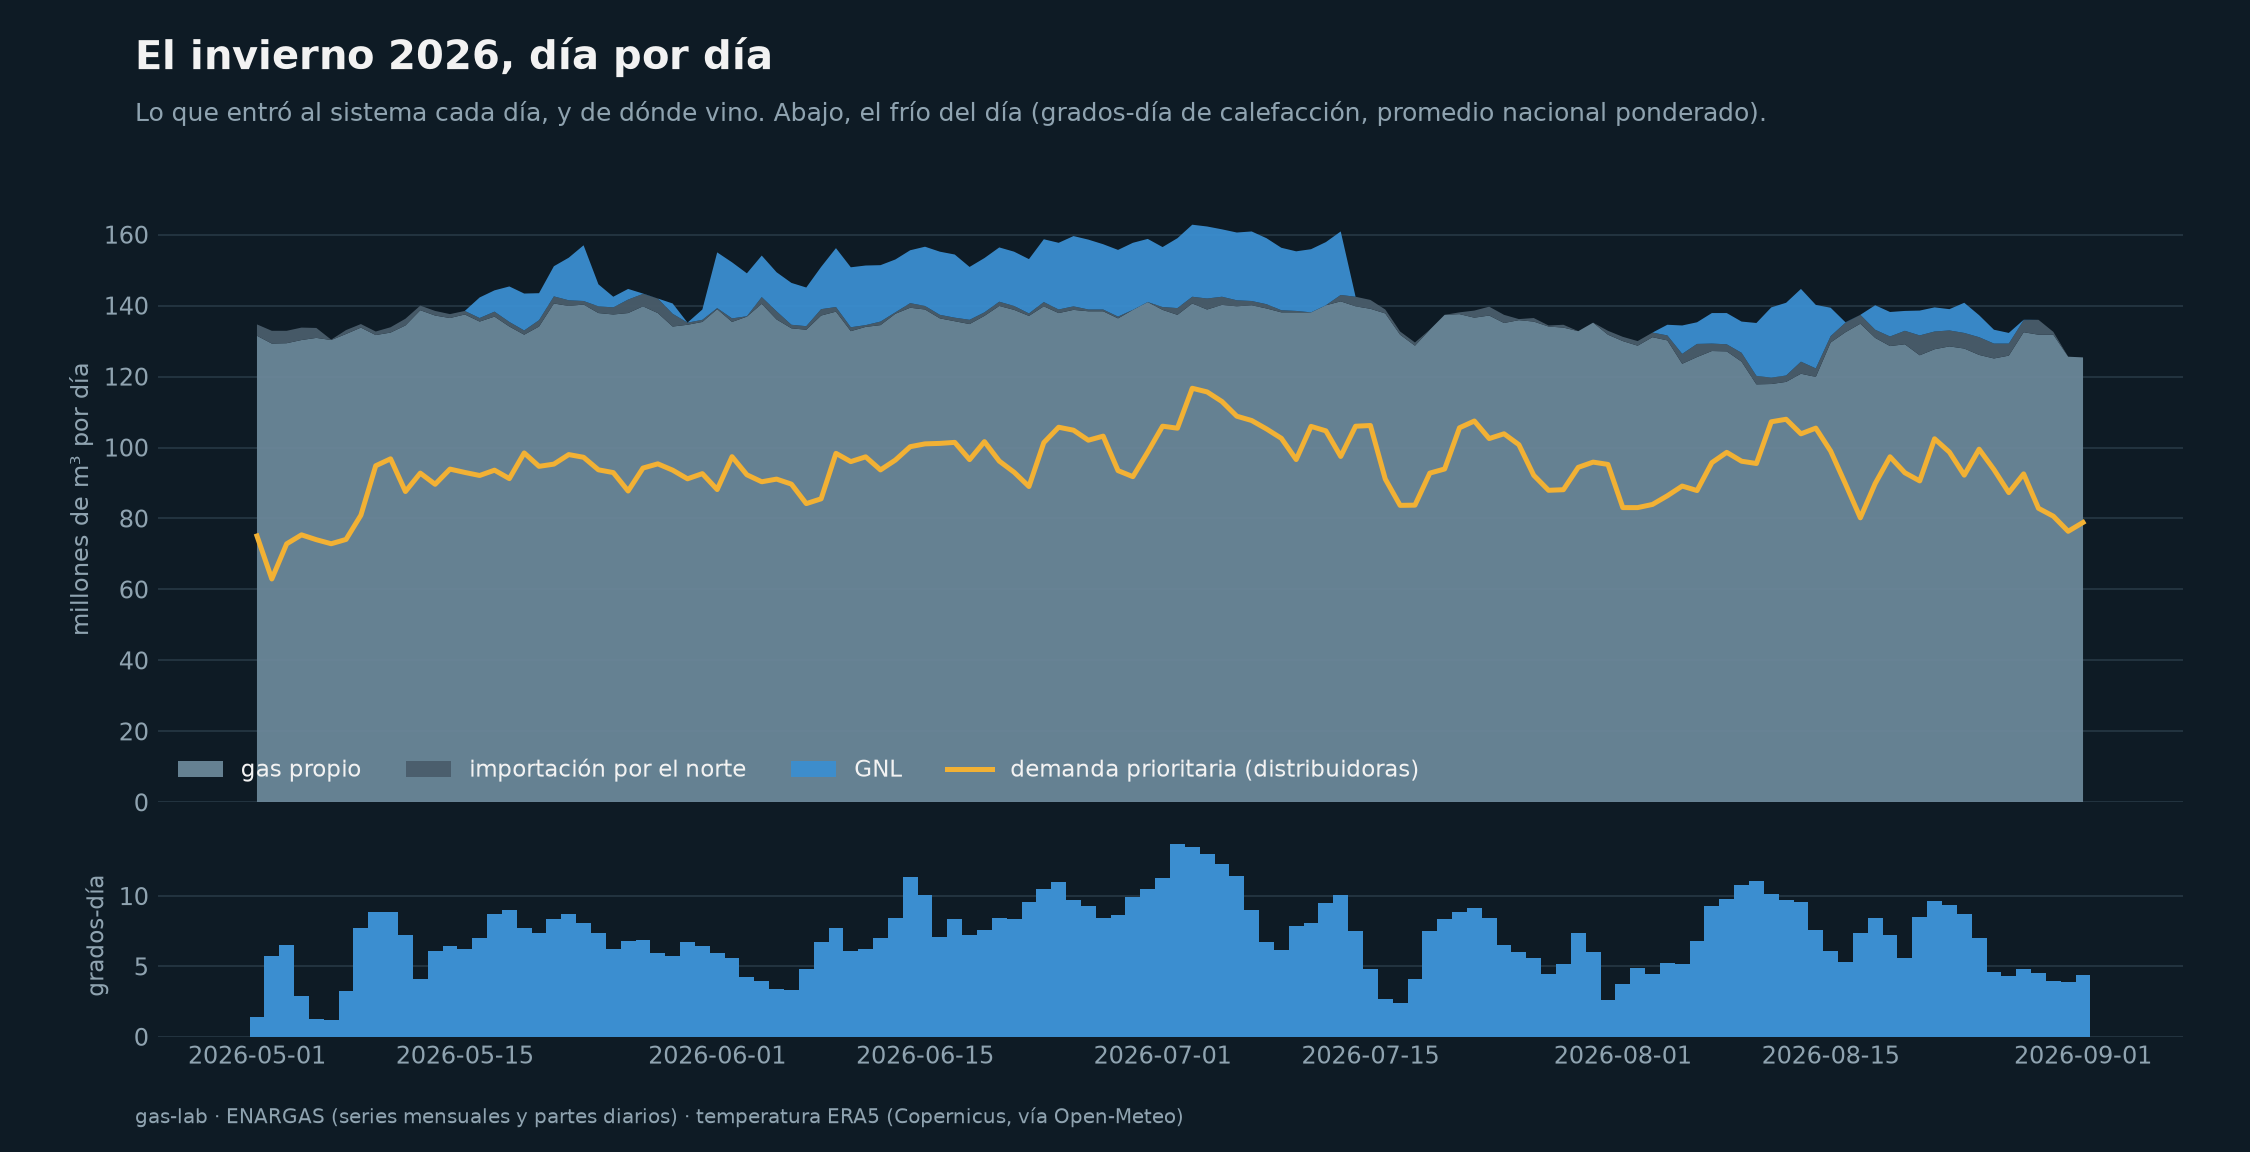

,hdd,prioritaria,directos,consumo,inyeccion,gnl,domestico
fecha,,,,,,,
2026-07-02,13.7,105.4,31.0,143.5,159.0,19.7,137.4
2026-07-03,13.5,116.7,30.6,154.9,162.8,20.3,140.6
2026-07-04,13.0,115.7,30.1,153.4,162.3,20.3,138.9
2026-07-05,12.3,113.0,25.8,146.2,161.5,19.0,140.2
2026-07-06,11.4,108.8,27.5,143.8,160.6,19.1,139.8


In [3]:
w26 = winter(D, 2026)
from glab.figuras import winter_days
winter_days(w26, FIGURES / "invierno_2026.png", 2026); display(Image(str(FIGURES / "invierno_2026.png")))
w26.nlargest(5, "hdd")[["hdd", "prioritaria", "directos", "consumo", "inyeccion", "gnl", "domestico"]].round(1)

## 3. La demanda prioritaria y el frío del día

La demanda de las distribuidoras se ajusta con los grados-día con inercia (las casas tardan en
enfriarse: el frío de ayer también cuenta), el fin de semana y el mes. Los clientes directos de
TGN y TGS, que son los que se cortan, se toman en su nivel de los días templados.

In [4]:
p = fit_priority(w26)
dirs, ov = unconstrained_direct(w26), overhead(w26)
techo = w26["domestico"].quantile(0.98)
print(f"demanda prioritaria: {p['por_hdd']:.2f} millones de m³/día por grado-día; R² {p['r2']:.2f}; error típico {p['sigma']:.1f}")
print(f"clientes directos sin cortes: {dirs:.1f}; diferencia entre inyección y consumo: {ov:.1f}; máximo de gas propio (p98): {techo:.1f} millones de m³/día")

demanda prioritaria: 3.39 millones de m³/día por grado-día; R² 0.76; error típico 4.6
clientes directos sin cortes: 28.6; diferencia entre inyección y consumo: 17.3; máximo de gas propio (p98): 140.6 millones de m³/día


## 4. La prueba: el invierno 2026 con su propio tiempo

Si el modelo sirve, el faltante físico que calcula con el tiempo real de 2026 tiene que parecerse
al GNL que entró.

In [5]:
g = season_gap(thermal(H)[w26.index], p, dirs, ov, techo)
cmp = pd.DataFrame({"faltante_calculado": g["falta"], "gnl_real": w26["gnl"]})
print(f"faltante calculado: {g.falta.sum():.0f} millones de m³ en {int((g.falta > 0).sum())} días · GNL real: {w26.gnl.sum():.0f} en {int((w26.gnl > 0.5).sum())} días")
print("correlación diaria:", round(cmp.corr().iloc[0, 1], 2))
cmp.resample("MS").sum().round(0).T

faltante calculado: 371 millones de m³ en 56 días · GNL real: 1017 en 78 días
correlación diaria: 0.64


fecha,2026-05-01,2026-06-01,2026-07-01,2026-08-01,2026-09-01
faltante_calculado,1.0,108.0,211.0,50.0,0.0
gnl_real,94.0,475.0,241.0,206.0,0.0


El calendario coincide, el volumen no: el GNL que entró es casi tres veces el faltante nacional
calculado. El balance del país no alcanza para explicarlo, por dos razones. El GNL entra por
Escobar, al lado del AMBA, y reemplaza gas propio que no llega por los gasoductos troncales
aunque el total nacional alcance: el cuello es regional. Y los buques se contratan antes del
invierno: el GNL de cada año se movió entre 860 y 1.280 millones de m³ desde 2021 sin relación con
el frío.

Por eso el invierno que viene se mide de dos maneras: el faltante físico nacional, que es el mínimo
que habría que cubrir, y el GNL que se usaría operando como en 2024 a 2026, ya con el gasoducto
Perito Moreno.

## 5. El invierno 2027 con el tiempo de cada invierno desde 1997

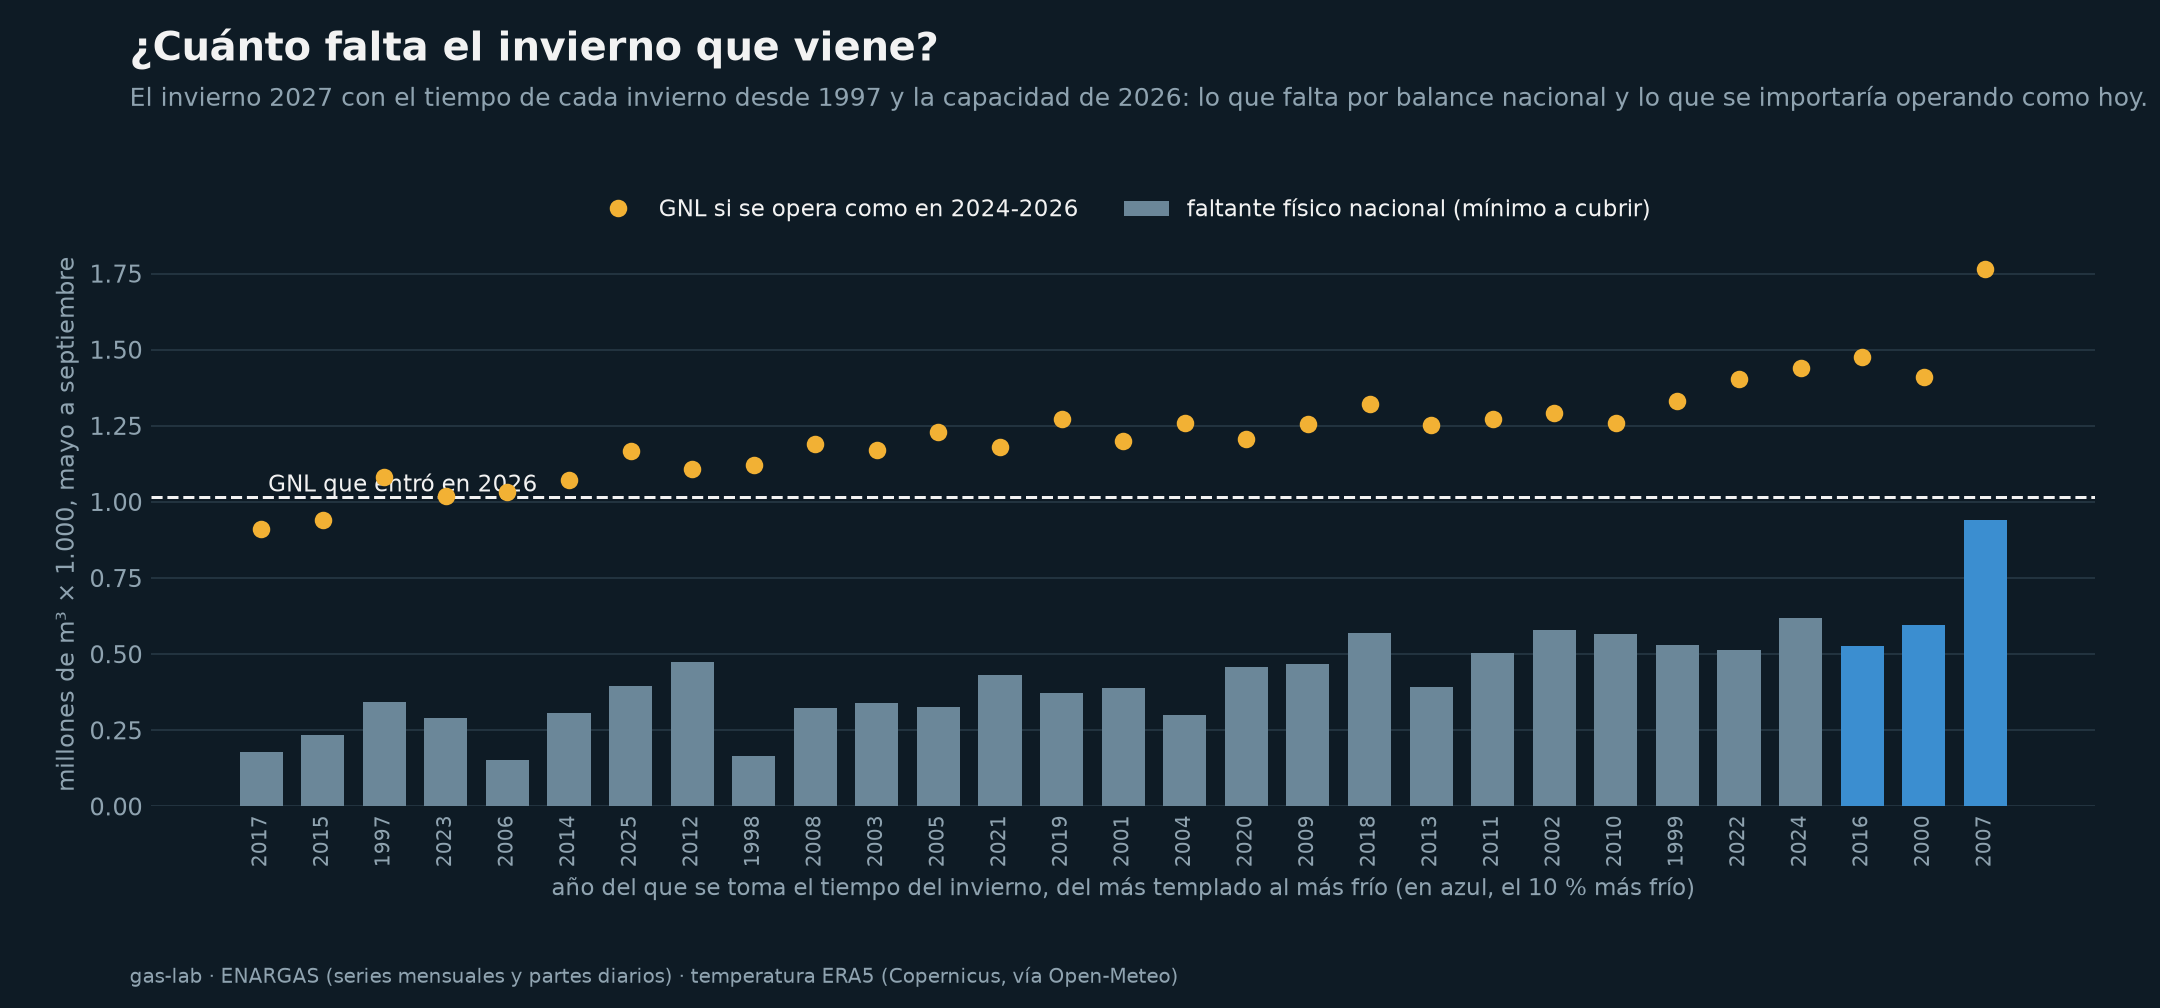

GNL medio por día según el frío, inviernos 2024-2026:


,dias,gnl_medio,prob_gnl
hdd_termico,,,
"[0, 4)",71,1.31,0.23
"[4, 6)",86,3.54,0.43
"[6, 8)",123,9.00,0.78
"[8, 10)",112,14.75,0.97
"[10, 12)",20,16.07,1.00
"[12, 30)",17,19.12,1.00


,dias_con_faltante,faltante_mm3,buques_faltante,pico_faltante,gnl_como_2024_2026,buques_operacion
cálido (p10),44.2,222.3,2.6,13.9,1030.8,12.1
normal (mediana),57.0,394.8,4.6,17.4,1230.5,14.5
frío (p90),72.4,583.7,6.9,26.8,1416.8,16.7


In [6]:
ens = winter_ensemble(H, p, dirs, ov, techo, range(1997, 2026))
resp = gnl_response(D, (2024, 2025, 2026))
ens["gnl_como_2024_2026"] = gnl_ensemble(H, resp, range(1997, 2026))
ens["buques_faltante"] = ens["faltante_mm3"] / M3_POR_BUQUE
ens["buques_operacion"] = ens["gnl_como_2024_2026"] / M3_POR_BUQUE
ens.to_csv(DATA_PROC / "invierno_2027.csv")
from glab.figuras import next_winter
next_winter(ens, {"2026": w26.gnl.sum()}, FIGURES / "invierno_2027.png"); display(Image(str(FIGURES / "invierno_2027.png")))
print("GNL medio por día según el frío, inviernos 2024-2026:"); display(resp.round(2))
q = ens.quantile([0.1, 0.5, 0.9])[["dias_con_faltante", "faltante_mm3", "buques_faltante", "pico_faltante", "gnl_como_2024_2026", "buques_operacion"]]
q.index = ["cálido (p10)", "normal (mediana)", "frío (p90)"]; q.round(1)

## Lo que dice y lo que no

- Con la capacidad de 2026, un invierno normal deja un faltante físico en unos 55 días, y uno frío
  en más de 70. Ninguno se cubre sin GNL o sin cortes.
- El GNL que efectivamente se compra es bastante más que ese mínimo, y no depende del frío: se
  contrata antes. Es un seguro, y también la forma de llevar gas al AMBA cuando los troncales
  están llenos.
- Todo supone la capacidad de transporte de 2026. Una ampliación del Perito Moreno o de la
  reversión del Norte cambia el techo y cambia la cuenta; el notebook se vuelve a correr con el
  techo nuevo.

## Límites

- Los partes diarios son datos provisorios de las licenciatarias. Faltan 32 partes de más de
  4.000.
- En los días de corte, la demanda directa observada ya está recortada. Se estima su nivel sin
  cortes con los días templados del mismo invierno, que pueden tener algo de corte también.
- El balance es nacional: no ve los cuellos por región, que es donde el GNL de Escobar hace
  diferencia.
- La inyección incluye la exportación que sale por el propio sistema y el combustible de las
  plantas compresoras; se toma su mediana como un número fijo.